# TP1 (a completer) : K-means + ACP — *Wine*

Remplacez chaque `...` et chaque `# TODO`. Le corrige est dans
`../notebooks/TP1_kmeans_acp.ipynb` (a ne consulter qu'en dernier recours).

**Objectif.** Retrouver, par clustering, les **3 cepages** de 178 vins decrits
par 13 mesures chimiques, sans utiliser l'etiquette ; puis valider et qualifier.

In [1]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [2]:
from sklearn.datasets import load_wine
ds = load_wine(as_frame=True)
X = ds.data
cepage = ds.target      # garde de cote pour la validation
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 1. Exploration
**Consigne.** Affichez la moyenne et l'ecart-type de chaque variable pour
constater les differences d'echelle.

In [3]:
# les echelles sont tres differentes, proline est a 746 en moyenne...
X.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


## 2.a Standardisation
**Consigne.** Standardisez `X` (moyenne 0, ecart-type 1) avec `StandardScaler`.

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = scaler.fit_transform(X)
print('standardisation ok, shape :', X_std.shape)

standardisation ok, shape : (178, 13)


## 2.b Choisir k
**Consigne.** Pour `k` de 2 a 8, entrainez un `KMeans` et stockez l'inertie
(`.inertia_`) et la silhouette (`silhouette_score`). Tracez les deux courbes et
deduisez `k_best` (k qui maximise la silhouette).

k retenu : 3


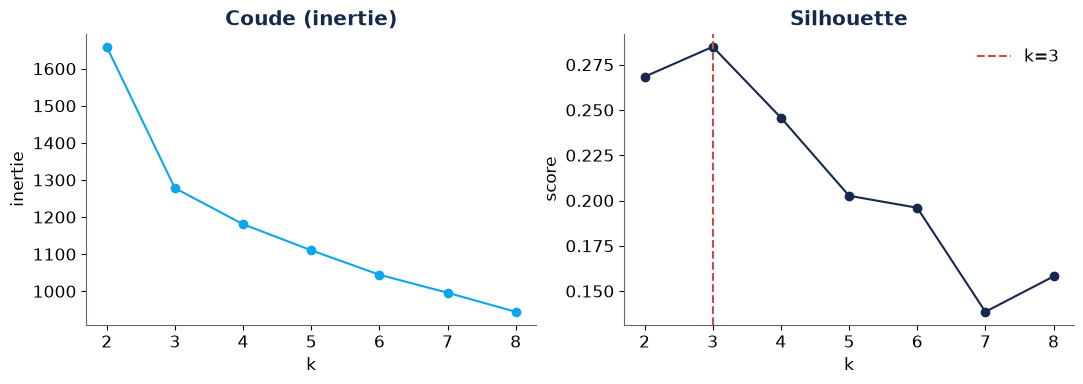

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 9)
inerties, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_std)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_std, km.labels_))

# on prend le k avec la meilleure silhouette, le coude est pas super net
meilleur_idx = silhouettes.index(max(silhouettes))
k_best = list(ks)[meilleur_idx]
print('k retenu :', k_best)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(list(ks), inerties, "-o", color=ACCENT)
ax1.set(title="Coude (inertie)", xlabel="k", ylabel="inertie")
ax2.plot(list(ks), silhouettes, "-o", color=NAVY)
ax2.axvline(k_best, color=RED, linestyle="--", label=f"k={k_best}")
ax2.set(title="Silhouette", xlabel="k", ylabel="score")
ax2.legend(frameon=False)
plt.tight_layout()
plt.show()

## 3. Evaluation + validation
**Consigne.** Entrainez le modele final avec `k_best`. Affichez l'inertie, la
silhouette, puis **validez** : calculez l'`adjusted_rand_score` entre `cepage` et
les clusters, et affichez le `pd.crosstab`.

In [6]:
from sklearn.metrics import adjusted_rand_score

km = KMeans(n_clusters=k_best, n_init=10, random_state=0).fit(X_std)
labels = km.labels_
# ARI proche de 1 = les clusters collent bien aux vrais cepages

sil = silhouette_score(X_std, labels)
ari = adjusted_rand_score(cepage, labels)
print('silhouette :', round(sil, 3))
print('ARI        :', round(ari, 3))

# tableau croise pour voir si les clusters correspondent aux cepages
pd.crosstab(labels, cepage, rownames=['cluster'], colnames=['cepage'])

silhouette : 0.285
ARI        : 0.897


cepage,0,1,2
cluster,,,
0,0,65,0
1,0,3,48
2,59,3,0


## 4. Visualisation ACP
**Consigne.** Projetez `X_std` en 2D avec `PCA(n_components=2)`, puis tracez un
nuage de points colore par cluster (ajoutez les centres si vous le souhaitez).

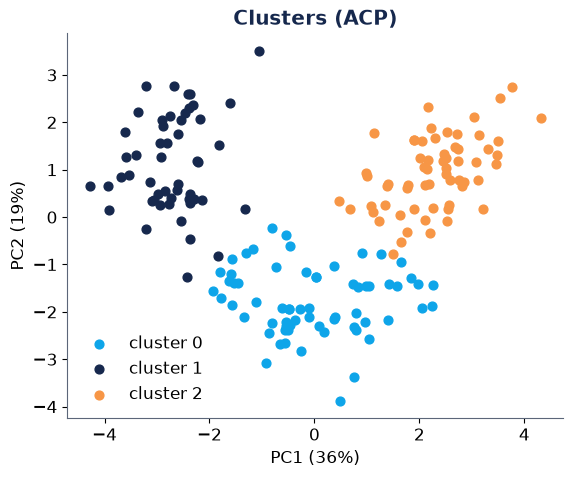

In [7]:
from sklearn.decomposition import PCA
# on projette en 2D pour visualiser, on perd de l'info mais ca suffit

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(X_std)
var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(6.4, 5))
for c in sorted(np.unique(labels)):
    m = labels == c
    ax.scatter(coords[m, 0], coords[m, 1], label=f'cluster {c}', color=PALETTE[c], s=40)
ax.set(title="Clusters (ACP)", xlabel=f"PC1 ({var[0]:.0%})", ylabel=f"PC2 ({var[1]:.0%})")
ax.legend(frameon=False)
plt.show()

## 5 & 6. Integration + qualification
**Consigne.** Ajoutez la colonne `cluster` a une copie de `X`, puis calculez le
profil moyen (`groupby`) des variables `alcohol`, `color_intensity`,
`flavanoids`, `proline` par cluster. Commentez les profils.

In [8]:
vins = X.copy()
vins['cluster'] = labels
# proline et alcohol sont probablement les plus utiles pour differencier
cles = ['alcohol', 'color_intensity', 'flavanoids', 'proline']

# profil moyen de chaque cluster sur les 4 variables cles
profil = vins.groupby('cluster')[cles].mean()
profil

,alcohol,color_intensity,flavanoids,proline
cluster,,,,
0,12.250923,2.973077,2.050000,510.169231
1,13.134118,7.234706,0.818824,619.058824
2,13.676774,5.453548,3.003226,1100.225806


## A rendre

**k retenu : k = 3.**
BC c'est le moment ou le coude est le plus bas sur le graphique d'inertie et le plus haut sur la sihoutte

**ARI obtenu : 0.897.**
Un ARI aussi proche de 1 signifie que le partitionnement obtenu par K-means,
construit uniquement a partir des mesures chimiques, retrouve presque
parfaitement les 3 cepages reels. Le tableau croise le confirme :
- le cluster 0 (65 vins) correspond integralement au cepage 1 ;
- le cluster 1 (51 vins) correspond presque entierement au cepage 2 (48/51) ;
- le cluster 2 (62 vins) correspond presque entierement au cepage 0 (59/62).

Seuls 6 vins du cepage 1 sont repartis dans les clusters 1 et 2 (3 chacun) :
le clustering n'est pas parfait mais l'accord avec les vrais cepages est tres
fort.

**Qualification des clusters :**
- **Cluster 0** (correspond au cepage 1) : profil le plus "leger", avec le
  taux d'alcool le plus bas (~12.3) et la proline la plus faible (~510) -
  des vins peu concentres.
- **Cluster 1** (correspond au cepage 2) : couleur tres marquee (intensite
  colorante la plus elevee, ~7.2) mais flavonoides tres faibles (~0.82) -
  des vins tanniques peu riches en flavonoides.
- **Cluster 2** (correspond au cepage 0) : profil le plus "riche", avec
  l'alcool le plus eleve (~13.7), des flavonoides eleves (~3.0) et une
  proline tres elevee (~1100) - des vins concentres et structures.

**Bonus.** Refaites l'analyse **sans** standardisation : que devient l'ARI ?